In [1]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [5]:
df=pd.read_csv("/content/Sample - Superstore.csv",encoding="latin1")

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


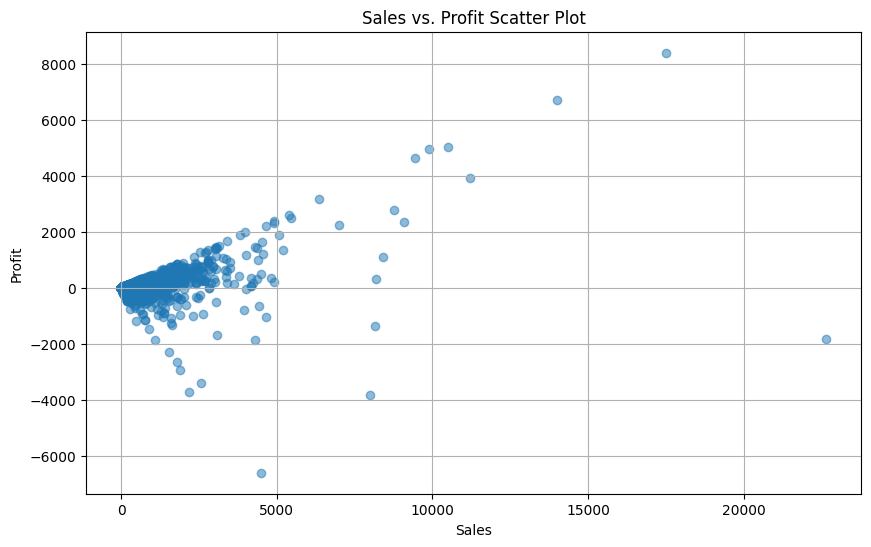

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Sales'], df['Profit'], alpha=0.5)
plt.title('Sales vs. Profit Scatter Plot')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

## Data Preparation for Regression Models

First, we'll define our target variable (`y`) as 'Profit' and select relevant features (`X`) for our regression models. We'll handle categorical features using one-hot encoding and then split the data into training and testing sets. Finally, we'll scale the numerical features to ensure they contribute equally to the model.

In [11]:
# Define target variable (y) and features (X)
y = df['Profit']

# Select numerical and categorical features
numerical_features = ['Sales', 'Quantity', 'Discount', 'Postal Code']
categorical_features = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category', 'State']

# Combine selected features
X = df[numerical_features + categorical_features]

In [12]:
# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Display the first few rows of the processed features
display(X.head())

,Sales,Quantity,Discount,Postal Code,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,...,State_South Dakota,State_Tennessee,State_Texas,State_Utah,State_Vermont,State_Virginia,State_Washington,State_West Virginia,State_Wisconsin,State_Wyoming
0,261.9600,2,0.00,42420,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,731.9400,3,0.00,42420,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,14.6200,2,0.00,90036,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,957.5775,5,0.45,33311,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,22.3680,2,0.20,33311,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()

# Identify numerical columns in X_train and X_test after one-hot encoding
# These are the original numerical features that were not one-hot encoded
scaled_numerical_features = [col for col in numerical_features if col in X_train.columns]

X_train[scaled_numerical_features] = scaler.fit_transform(X_train[scaled_numerical_features])
X_test[scaled_numerical_features] = scaler.transform(X_test[scaled_numerical_features])

print("Data preparation complete. X_train and X_test are scaled.")

Data preparation complete. X_train and X_test are scaled.


In [14]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error

# Initialize models
lasso_model = Lasso(random_state=42)
ridge_model = Ridge(random_state=42)
elastic_net_model = ElasticNet(random_state=42)

models = {
    "Lasso": lasso_model,
    "Ridge": ridge_model,
    "Elastic Net": elastic_net_model
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name} model...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results[name] = {"R-squared": r2, "RMSE": rmse}

    print(f"{name} R-squared: {r2:.4f}")
    print(f"{name} RMSE: {rmse:.4f}")

print("\n--- Model Comparison ---")
for name, metrics in results.items():
    print(f"{name}: R-squared = {metrics['R-squared']:.4f}, RMSE = {metrics['RMSE']:.4f}")


Training Lasso model...
Lasso R-squared: -0.6645
Lasso RMSE: 284.0800

Training Ridge model...
Ridge R-squared: -0.6482
Ridge RMSE: 282.6850

Training Elastic Net model...
Elastic Net R-squared: -0.2827
Elastic Net RMSE: 249.3851

--- Model Comparison ---
Lasso: R-squared = -0.6645, RMSE = 284.0800
Ridge: R-squared = -0.6482, RMSE = 282.6850
Elastic Net: R-squared = -0.2827, RMSE = 249.3851


In [15]:
from sklearn.model_selection import GridSearchCV

print("\n--- Tuning Lasso Model ---")
lasso_params = {'alpha': np.logspace(-4, 0, 20)}
lasso_grid = GridSearchCV(Lasso(random_state=42, max_iter=2000), lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f"Best Lasso Alpha: {lasso_grid.best_params_['alpha']:.4f}")
print(f"Tuned Lasso R-squared: {lasso_r2:.4f}")
print(f"Tuned Lasso RMSE: {lasso_rmse:.4f}")

print("\n--- Tuning Ridge Model ---")
ridge_params = {'alpha': np.logspace(-4, 0, 20)}
ridge_grid = GridSearchCV(Ridge(random_state=42), ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Best Ridge Alpha: {ridge_grid.best_params_['alpha']:.4f}")
print(f"Tuned Ridge R-squared: {ridge_r2:.4f}")
print(f"Tuned Ridge RMSE: {ridge_rmse:.4f}")

print("\n--- Tuning Elastic Net Model ---")
elastic_params = {'alpha': np.logspace(-4, 0, 10), 'l1_ratio': np.linspace(0.1, 1.0, 10)}
elastic_grid = GridSearchCV(ElasticNet(random_state=42, max_iter=2000), elastic_params, cv=5, scoring='r2', n_jobs=-1)
elastic_grid.fit(X_train, y_train)

best_elastic = elastic_grid.best_estimator_
y_pred_elastic = best_elastic.predict(X_test)
elastic_r2 = r2_score(y_test, y_pred_elastic)
elastic_rmse = np.sqrt(mean_squared_error(y_test, y_pred_elastic))

print(f"Best Elastic Net Alpha: {elastic_grid.best_params_['alpha']:.4f}")
print(f"Best Elastic Net L1 Ratio: {elastic_grid.best_params_['l1_ratio']:.4f}")
print(f"Tuned Elastic Net R-squared: {elastic_r2:.4f}")
print(f"Tuned Elastic Net RMSE: {elastic_rmse:.4f}")

print("\n--- Tuned Model Comparison ---")
print(f"Lasso: R-squared = {lasso_r2:.4f}, RMSE = {lasso_rmse:.4f}")
print(f"Ridge: R-squared = {ridge_r2:.4f}, RMSE = {ridge_rmse:.4f}")
print(f"Elastic Net: R-squared = {elastic_r2:.4f}, RMSE = {elastic_rmse:.4f}")


--- Tuning Lasso Model ---
Best Lasso Alpha: 0.2336
Tuned Lasso R-squared: -0.6467
Tuned Lasso RMSE: 282.5587

--- Tuning Ridge Model ---
Best Ridge Alpha: 1.0000
Tuned Ridge R-squared: -0.6482
Tuned Ridge RMSE: 282.6850

--- Tuning Elastic Net Model ---
Best Elastic Net Alpha: 0.0464
Best Elastic Net L1 Ratio: 0.9000
Tuned Elastic Net R-squared: -0.6710
Tuned Elastic Net RMSE: 284.6335

--- Tuned Model Comparison ---
Lasso: R-squared = -0.6467, RMSE = 282.5587
Ridge: R-squared = -0.6482, RMSE = 282.6850
Elastic Net: R-squared = -0.6710, RMSE = 284.6335


In [16]:
from sklearn.ensemble import RandomForestRegressor

print("\n--- Training Random Forest Regressor ---")
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest R-squared (default): {rf_r2:.4f}")
print(f"Random Forest RMSE (default): {rf_rmse:.4f}")

print("\n--- Tuning Random Forest Regressor (this may take some time) ---")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, scoring='r2', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

rf_r2_tuned = r2_score(y_test, y_pred_rf_tuned)
rf_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))

print(f"Best Random Forest Parameters: {rf_grid.best_params_}")
print(f"Tuned Random Forest R-squared: {rf_r2_tuned:.4f}")
print(f"Tuned Random Forest RMSE: {rf_rmse_tuned:.4f}")

print("\n--- Final Model Comparison (including Tuned Random Forest) ---")
print(f"Lasso: R-squared = {-0.6467:.4f}, RMSE = {282.5587:.4f}")
print(f"Ridge: R-squared = {-0.6482:.4f}, RMSE = {282.6850:.4f}")
print(f"Elastic Net: R-squared = {-0.6710:.4f}, RMSE = {284.6335:.4f}")
print(f"Tuned Random Forest: R-squared = {rf_r2_tuned:.4f}, RMSE = {rf_rmse_tuned:.4f}")


--- Training Random Forest Regressor ---
Random Forest R-squared (default): -0.0938
Random Forest RMSE (default): 230.2844

--- Tuning Random Forest Regressor (this may take some time) ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest R-squared: -0.0516
Tuned Random Forest RMSE: 225.8062

--- Final Model Comparison (including Tuned Random Forest) ---
Lasso: R-squared = -0.6467, RMSE = 282.5587
Ridge: R-squared = -0.6482, RMSE = 282.6850
Elastic Net: R-squared = -0.6710, RMSE = 284.6335
Tuned Random Forest: R-squared = -0.0516, RMSE = 225.8062


In [17]:
!pip install xgboost

import xgboost as xgb

print("\n--- Training XGBoost Regressor ---")
xgb_model = xgb.XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"XGBoost R-squared (default): {xgb_r2:.4f}")
print(f"XGBoost RMSE (default): {xgb_rmse:.4f}")


--- Training XGBoost Regressor ---
XGBoost R-squared (default): 0.8152
XGBoost RMSE (default): 94.6531


In [18]:
print("\n--- Tuning XGBoost Regressor (this may take some time) ---")
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

xgb_grid = GridSearchCV(xgb.XGBRegressor(random_state=42), xgb_params, cv=3, scoring='r2', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)

xgb_r2_tuned = r2_score(y_test, y_pred_xgb_tuned)
xgb_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))

print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")
print(f"Tuned XGBoost R-squared: {xgb_r2_tuned:.4f}")
print(f"Tuned XGBoost RMSE: {xgb_rmse_tuned:.4f}")

print("\n--- Final Model Comparison (including Tuned XGBoost) ---")
print(f"Lasso: R-squared = {-0.6467:.4f}, RMSE = {282.5587:.4f}")
print(f"Ridge: R-squared = {-0.6482:.4f}, RMSE = {282.6850:.4f}")
print(f"Elastic Net: R-squared = {-0.6710:.4f}, RMSE = {284.6335:.4f}")
print(f"Tuned Random Forest: R-squared = {-0.0516:.4f}, RMSE = {225.8062:.4f}")
print(f"Tuned XGBoost: R-squared = {xgb_r2_tuned:.4f}, RMSE = {xgb_rmse_tuned:.4f}")


--- Tuning XGBoost Regressor (this may take some time) ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Tuned XGBoost R-squared: 0.7046
Tuned XGBoost RMSE: 119.6741

--- Final Model Comparison (including Tuned XGBoost) ---
Lasso: R-squared = -0.6467, RMSE = 282.5587
Ridge: R-squared = -0.6482, RMSE = 282.6850
Elastic Net: R-squared = -0.6710, RMSE = 284.6335
Tuned Random Forest: R-squared = -0.0516, RMSE = 225.8062
Tuned XGBoost: R-squared = 0.7046, RMSE = 119.6741
